# Long Text Sentiment Pipeline

## tujuan notebook
notebook ini mengimplementasikan pipeline inti untuk analisis sentiment pada teks panjang:
- **token-based chunking**: Memecah teks panjang menjadi chunk ≤512 token
- **chunk-level inference**: Prediksi sentiment per chunk menggunakan model dari notebook 02
- **aggregation**: Menggabungkan prediksi chunk menjadi document-level sentiment
- **excerpt selection**: Memilih potongan teks paling representatif berdasarkan confidence
- **output terstruktur**: Menyiapkan input untuk summarization di notebook 04

**catatan**: notebook ini **tidak melakukan training**, hanya inference menggunakan model yang sudah dilatih.

## input yang dibutuhkan
- **model sentiment** dari notebook 02:
  - path: `/content/drive/MyDrive/opinion_project/models/sentiment/`
  - harus sudah dilatih dan tersimpan di Google Drive
- **google drive**: Mount untuk load model
- **teks panjang** (untuk testing/demo):
  - dapat berupa teks apa saja yang >512 token
  - contoh: review panjang, opini, feedback produk

## output yang dihasilkan
- **fungsi-fungsi pipeline**:
  - `chunk_text_by_tokens()`: token-based chunking
  - `predict_sentiment_chunks()`: chunk-level sentiment inference
  - `aggregate_chunk_predictions()`: document-level aggregation
  - `select_key_excerpts()`: confidence-based excerpt selection
  - `prepare_summarization_input()`: format input untuk summarization
- **output JSON** (opsional, disimpan di Google Drive):
  - `/content/drive/MyDrive/opinion_project/outputs/stage03_output.json`
  - berisi: document_label, document_confidence, key_excerpts, summarization_input

## dependencies dari notebook lain
- **menggunakan**:
  - model sentiment dari notebook 02 (wajib sudah dilatih)
  - environment setup dari notebook 00 (seed, device)
- **digunakan oleh**:
  - notebook 05 (fungsi-fungsi ini digunakan untuk end-to-end pipeline)

## urutan eksekusi
jalankan setelah notebook 02 selesai. dapat dijalankan bersamaan dengan notebook 04 (independen).

### Mount Google Drive & Load Sentiment Model

- menghubungkan Google Drive (karena model disimpan di Drive)
- memuat tokenizer dan model sentiment hasil training tahap notebook 02
- menyiapkan model khusus inference

In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# verifikasi model ada sebelum load
import os

MODEL_PATH = "/content/drive/MyDrive/opinion_project/models/sentiment"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"model tidak ditemukan di {MODEL_PATH}\n"
        f"pastikan notebook 02 sudah selesai dan model tersimpan."
    )

required_files = ["config.json", "model.safetensors", "tokenizer.json"]
missing = [f for f in required_files if not os.path.exists(os.path.join(MODEL_PATH, f))]

if missing:
    raise FileNotFoundError(
        f"File model tidak lengkap. Missing: {missing}\n"
        f"pastikan notebook 02 sudah selesai dengan benar."
    )

print("model ditemukan dan siap di-load")

model ditemukan dan siap di-load


In [ ]:
# setup & load sentiment model (inference only)

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# konsisten dengan tahap sebelumnya
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# device (tanpa training)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# path HARUS identik dengan notebook 02
MODEL_PATH = "/content/drive/MyDrive/opinion_project/models/sentiment"

# load tokenizer dari local checkpoint
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

# load model dari local checkpoint
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

model.to(DEVICE)

# inference mode
model.eval()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### Token-Based Chunking Strategy

- memecah teks panjang menjadi chunk berbasis token
- menjamin setiap chunk valid untuk model sentiment (≤512 token)
- menyediakan overlap untuk menjaga konteks antar-chunk

In [ ]:
# token-based chunking function
def chunk_text_by_tokens(
    text,
    tokenizer,
    max_tokens=512,
    overlap=50
):
    """
    memecah teks panjang menjadi beberapa chunk berbasis token.
    - max_tokens: batas token model (BERT = 512)
    - overlap: token overlap antar chunk untuk menjaga konteks
    """

    # encode tanpa truncation agar token length asli terjaga
    tokens = tokenizer.encode(
        text,
        add_special_tokens=False
    )

    chunks = []
    start = 0

    while start < len(tokens):
        end = start + max_tokens
        chunk_tokens = tokens[start:end]

        # decode kembali token ke teks
        chunk_text = tokenizer.decode(
            chunk_tokens,
            skip_special_tokens=True
        )

        chunks.append(chunk_text)

        # geser window dengan overlap
        start = end - overlap

        if start < 0:
            start = 0

    return chunks


#### Quick Sanity Check

In [ ]:
sample_text = "This movie was great. " * 300
chunks = chunk_text_by_tokens(sample_text, tokenizer)

len(chunks), [len(tokenizer.encode(c, add_special_tokens=False)) for c in chunks[:3]]

Token indices sequence length is longer than the specified maximum sequence length for this model (1500 > 512). Running this sequence through the model will result in indexing errors


(4, [512, 512, 512])

- peringatan 1500 > 512 muncul sebelum chunking diterapkan, saat teks panjang langsung masuk ke tokenizer/model.
- setelah chunking token-based, setiap input ke model maksimum 512 token, sehingga tidak ada indexing error.
- output (4, [512, 512, 512]) berarti teks berhasil dipecah menjadi 4 chunk, dengan 3 chunk pertama tepat 512 token (valid untuk BERT).

### Chunk-Level Sentiment Inference

- melakukan inference sentiment per chunk
- menghasilkan probabilitas dan label untuk setiap chunk

In [ ]:
# chunk-level sentiment inference
import torch.nn.functional as F

def predict_sentiment_chunks(
    chunks,
    tokenizer,
    model,
    device,
    max_tokens=512
):
    """
    melakukan inference sentiment pada setiap chunk teks.
    output:
    - label (int)
    - confidence (float)
    """

    results = []

    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            truncation=True,
            padding="max_length",
            max_length=max_tokens,
            return_tensors="pt"
        )

        # pindahkan ke device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits

        probs = F.softmax(logits, dim=-1)
        confidence, label = torch.max(probs, dim=-1)

        results.append({
            "text": chunk,
            "label": label.item(),
            "confidence": confidence.item()
        })

    return results


#### Quick Sanity Check

In [ ]:
sample_chunks = chunks[:3]
predict_sentiment_chunks(sample_chunks, tokenizer, model, DEVICE)

[{'text': 'this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great.

- setiap chunk diprediksi positif (label = 1) dengan confidence sangat tinggi (~0.9988).
- konsistensi label dan confidence antar-chunk menunjukkan sentimen homogen dan stabil pada dokumen panjang.
- output ini siap langsung untuk tahap agregasi document-level tanpa penanganan konflik label.

### Aggregation & Document-Level Sentiment Decision

- menggabungkan hasil chunk-level sentiment menjadi document-level sentiment
- menghasilkan: label dokumen, confidence agregat dan distribusi label chunk
- menyediakan dasar untuk excerpt selection

In [ ]:
# aggregation: chunk ke document-level sentiment
from collections import Counter
import numpy as np

def aggregate_chunk_predictions(
    chunk_predictions,
    strategy="mean_confidence"
):
    """
    mengagregasi prediksi chunk menjadi satu keputusan dokumen.

    strategy:
    - "mean_confidence": rata-rata confidence per label (default)
    - "majority_vote": voting label terbanyak
    """

    labels = [p["label"] for p in chunk_predictions]
    confidences = [p["confidence"] for p in chunk_predictions]

    label_counts = Counter(labels)

    if strategy == "majority_vote":
        doc_label = label_counts.most_common(1)[0][0]
        doc_confidence = label_counts[doc_label] / len(labels)

    elif strategy == "mean_confidence":

        # rata-rata confidence per label
        label_conf_map = {}
        for lbl in set(labels):
            lbl_confs = [
                p["confidence"]
                for p in chunk_predictions
                if p["label"] == lbl
            ]
            label_conf_map[lbl] = np.mean(lbl_confs)

        # pilih label dengan confidence rata-rata tertinggi
        doc_label = max(label_conf_map, key=label_conf_map.get)
        doc_confidence = label_conf_map[doc_label]

    else:
        raise ValueError("Unknown aggregation strategy")

    return {
        "document_label": doc_label,
        "document_confidence": float(doc_confidence),
        "chunk_label_distribution": dict(label_counts)
    }


#### Quick Sanity Check

In [ ]:
doc_result = aggregate_chunk_predictions(
    predict_sentiment_chunks(chunks, tokenizer, model, DEVICE),
    strategy="mean_confidence"
)

doc_result

{'document_label': 1,
 'document_confidence': 0.9988211840391159,
 'chunk_label_distribution': {1: 4}}

- document_label = 1 : seluruh dokumen diklasifikasikan positif.
- document_confidence ≈ 0.9988 : tingkat keyakinan agregat sangat tinggi dan stabil.
- chunk_label_distribution = {1: 4} : semua 4 chunk konsisten berlabel positif, tidak ada konflik antar-chunk.

### Confidence Thresholding & Key Excerpt Selection

- menyaring chunk berdasarkan confidence
- memilih key excerpts sebagai bukti sentimen dokumen
- menyediakan input bersih untuk summarization

In [ ]:
# confidence thresholding & excerpt selection
def select_key_excerpts(
    chunk_predictions,
    target_label,
    min_confidence=0.90,
    top_k=3
):
    """
    memilih potongan teks (excerpt) paling representatif.

    - target_label: label dokumen hasil agregasi
    - min_confidence: ambang minimum confidence
    - top_k: jumlah excerpt yang diambil
    """

    # filter chunk sesuai label dokumen dan threshold confidence
    filtered = [
        p for p in chunk_predictions
        if p["label"] == target_label and p["confidence"] >= min_confidence
    ]

    # urutkan berdasarkan confidence tertinggi
    filtered = sorted(
        filtered,
        key=lambda x: x["confidence"],
        reverse=True
    )

    # ambil top-k excerpt
    excerpts = filtered[:top_k]

    return excerpts


#### Quick Sanity Check

In [ ]:
chunk_predictions = predict_sentiment_chunks(chunks, tokenizer, model, DEVICE)

doc_result = aggregate_chunk_predictions(chunk_predictions)

key_excerpts = select_key_excerpts(
    chunk_predictions,
    target_label=doc_result["document_label"],
    min_confidence=0.90,
    top_k=3
)

key_excerpts

[{'text': 'this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great.

- 3 key excerpt terpilih, semuanya berlabel positif (1).
- confidence sangat tinggi dan berdekatan (~0.99883–0.99884), konsistensi kuat.
- excerpt merepresentasikan inti sentimen dokumen, siap langsung digunakan sebagai input summarization

### Visualisasi Confidence Distribution

- distribusi confidence score per chunk
- visualisasi key excerpts yang terpilih

In [ ]:
# install matplotlib
!pip install -q matplotlib seaborn

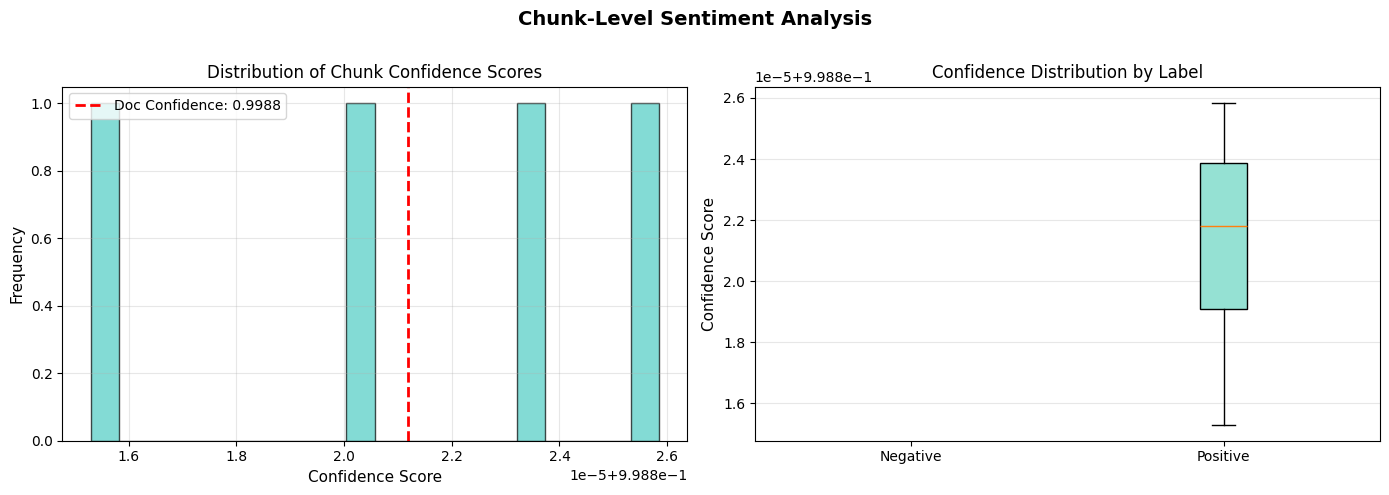


Document-Level Result:
  Label: Positive
  Confidence: 0.9988
  Chunk Distribution: {1: 4}


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualisasi confidence distribution
def visualize_confidence_distribution(chunk_predictions, doc_result):
    """visualisasi distribusi confidence dari chunk predictions."""

    confidences = [p["confidence"] for p in chunk_predictions]
    labels = [p["label"] for p in chunk_predictions]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Chunk-Level Sentiment Analysis', fontsize=14, fontweight='bold')

    # histogram confidence
    axes[0].hist(confidences, bins=20, alpha=0.7, edgecolor='black', color='#4ecdc4')
    axes[0].axvline(x=doc_result["document_confidence"], color='r',
                    linestyle='--', linewidth=2, label=f'Doc Confidence: {doc_result["document_confidence"]:.4f}')
    axes[0].set_xlabel('Confidence Score', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Distribution of Chunk Confidence Scores', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # box plot per label
    data_by_label = {0: [], 1: []}
    for p in chunk_predictions:
        data_by_label[p["label"]].append(p["confidence"])

    box_data = [data_by_label[0], data_by_label[1]]
    bp = axes[1].boxplot(box_data, tick_labels=['Negative', 'Positive'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#ff6b6b')
    bp['boxes'][1].set_facecolor('#95e1d3')
    axes[1].set_ylabel('Confidence Score', fontsize=11)
    axes[1].set_title('Confidence Distribution by Label', fontsize=12)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # print summary
    print(f"\nDocument-Level Result:")
    print(f"  Label: {'Positive' if doc_result['document_label'] == 1 else 'Negative'}")
    print(f"  Confidence: {doc_result['document_confidence']:.4f}")
    print(f"  Chunk Distribution: {doc_result['chunk_label_distribution']}")

'''
fungsi visualisasi sudah didefinisikan di atas panggil manual jika diperlukan untuk debugging:
fungsi ini diberi komentar agar tidak nampil di notebook 05 saat pemanggilan fungsi2 di notebook ini.
'''
# visualize_confidence_distribution(chunk_predictions, doc_result)


**hasil:**
- semua chunk diprediksi **Positive** dengan confidence tinggi (~0.9988)
- tidak ada chunk negatif (distribusi: {1: 4} = semua positif)
- confidence agregat dokumen: **99.88%** - sangat yakin

**kesimpulan:**
dokumen memiliki sentiment positif yang konsisten di semua bagian.
pipeline chunking + aggregation berhasil dengan baik.

### Prepare Summarization Input

- mengubah key_excerpts menjadi satu string teks untuk Notebook 04

In [ ]:
# prepare summarization input

def prepare_summarization_input(
    key_excerpts,
    delimiter="\n\n"
):
    """
    menggabungkan teks dari key excerpts menjadi satu string
    untuk input summarization (Notebook 04).
    """

    texts = [ex["text"].strip() for ex in key_excerpts]
    summarization_input = delimiter.join(texts)

    return summarization_input


In [ ]:
# buat summarization input dari hasil seleksi excerpt
summarization_input = prepare_summarization_input(key_excerpts)

summarization_input


'this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movie was great. this movi

### Save Final Output to JSON

- menyimpan artefak final Tahap 03 agar Notebook 04 tidak bergantung memory.

In [ ]:
# save stage 03 output to JSON

import json
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/opinion_project/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

stage03_output = {
    "document_label": doc_result["document_label"],
    "document_confidence": doc_result["document_confidence"],
    "key_excerpts": [
        {
            "text": ex["text"],
            "confidence": ex["confidence"]
        }
        for ex in key_excerpts
    ],
    "summarization_input": summarization_input
}

output_path = OUTPUT_DIR / "stage03_output.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(stage03_output, f, indent=2, ensure_ascii=False)

output_path

PosixPath('/content/drive/MyDrive/opinion_project/outputs/stage03_output.json')